In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df_ratings  = pd.read_csv("data/ratings.csv")
df_movies = pd.read_csv("data/movies.csv")
df_ratings.head()
df_movies.head()

In [ ]:
num_users = df_ratings["userId"].nunique()
num_movies = df_ratings["movieId"].nunique() #estakhdemna de mesh movies.csv ashan de el feeha el moveies el watched
num_ratings = len(df_ratings)
sparsity = 1 - (num_ratings / (num_movies * num_users)) #fraction of the user-movie matrix el fady w benhsebha ashan ne3raf el matrix feeha ad eh data
print("number of users = "+ str(num_users) +", number of movies = "+ str(num_movies)+ ", number of ratings = "+ str(num_ratings)+ ", sparsity = " +str(sparsity)) 

In [56]:
rating_matrix = df_ratings.pivot_table(index = "userId", columns = "movieId", values = "rating") #hatena fe table kol user leeh row wahed w kol column el movies el shafha w el value el gowa heya el rating w lw mafish khaliha Nan, helwa ashan ehna ben-compare el ratings beta3et kol user l kol movie
print(rating_matrix.shape)
print(rating_matrix.notna().sum().sum())

(610, 9724)
100836


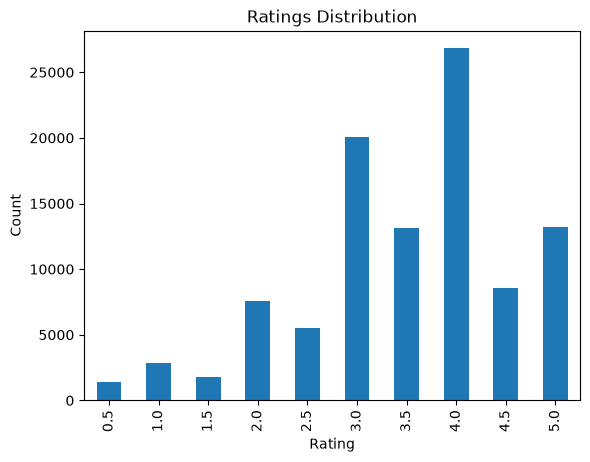

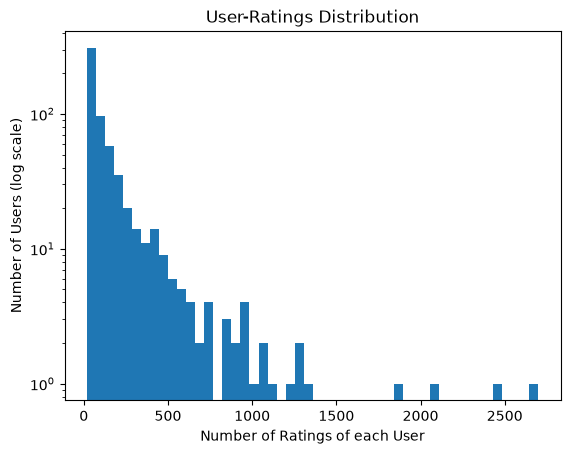

count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
Name: rating, dtype: float64


In [55]:
df_ratings["rating"].value_counts().sort_index().plot(kind="bar", ) #da beyruh l table el ratings w bey-count kol distinct rating fe meno kam w beysot mn el 3adad el kebeer lel soghayar ehna aizeen nesort by el rating number mesh count fa ashan keda amla el sort index w ba3mel bar graph
                                                                  #how often each rating appears
plt.xlabel("Rating")  
plt.ylabel("Count")    
plt.title("Ratings Distribution")
plt.show()
ratings_per_user = df_ratings.groupby("userId")["rating"].count()#beyshouf kol user amal kam rating w yehothom fer histogram
ratings_per_user.plot(kind="hist", bins=50) 
plt.xlabel("Number of Ratings of each User")  
plt.ylabel("Number of Users (log scale)")  
plt.yscale("log")
plt.title("User-Ratings Distribution")
plt.show()
print(ratings_per_user.describe()) #ashan n-observe



In [ ]:
def euclidean_similarity(vec1,vec2):
    d = 0
    for i in range(len(vec1)):
        d = d + np.square(vec1[i] - vec2[i])
    return 1/(1+np.sqrt(d))    

A = [5, 4, 5, 3] 
B = [3, 2, 3, 1] 
print(euclidean_similarity(A,B))

In [ ]:
def cosine_similarity(vec1, vec2):
    if(np.sum(vec1) == 0 or np.sum(vec2) == 0):
        print("Zero vector detected. Cannot caluclate cosine_similarity")
    if(len(vec1) == 1 ):
        print("there is a single element in one of teh vectors. Cannot caluclate cosine_similarity")
        return None
    return np.dot(vec1, vec2) / (np.sqrt(np.sum(np.array (vec1)*vec1)) * np.sqrt(np.sum(np.array (vec2)*vec2))) # or use np.linalg.norm(vec1) el norm da shabah pythagorean theorem bas l kol el vector w ma3nah how far the point is from the origin w da esmo length of the vector 
A = [5, 4, 5, 3] 
B = [3, 2, 3, 1] 
print(cosine_similarity(A,B))

In [ ]:
def pearson_similarity(vec1, vec2):
    return cosine_similarity(vec1 - np.mean(vec1), vec2 - np.mean(vec2))
A = [5, 4, 5, 3] 
B = [3, 2, 3, 1] 
print(pearson_similarity(A,B))

In [ ]:
def get_co_rated(matrix, a, b, axis):
    if axis == "index":
        s1 = matrix.loc[a, :]
        s2 = matrix.loc[b, :]
    elif axis == "columns":
        s1 = matrix.loc[:, a]
        s2 = matrix.loc[:, b]
    else:
        print("error")
        return None
    s1_mask = s1.notna()
    s2_mask = s2.notna()
    s_mask= s1_mask & s2_mask
    v1 = s1[s_mask].to_numpy()
    v2 = s2[s_mask].to_numpy()
    return v1, v2

In [ ]:
def find_k_nearest_users(matrix, target_user, k, similarity_fn):
        similarities = [] #store users and theit similarity to target user
        for user in matrix.index :
                if user == target_user:
                        continue #3ashn i dont compare user b nafso 
                vec1 , vec2 = get_co_rated(matrix, target_user, user, axis="index")
                if len(vec1)<2 :
                    continue
                score = similarity_fn(vec1, vec2)
                similarities.append((user,score))
        similarities.sort(key=lambda x: x[1], reverse=True) #sort from high to low (ai helped )
        return similarities[:k] #return k nearest neighbors
                
        
      

In [ ]:
def predict_rating_user_based(matrix, target_user, target_item, k, similarity_fn):
        neighbors = find_k_nearest_users(matrix,target_user,k,similarity_fn)
        ws=0 #weighted sum
        ss=0 #similarity sum
        for neighbor, similarity in neighbors:
                rating = matrix.loc[neighbor,target_item]
                if not np.isnan(rating):# check law feh rating
                        ws += similarity * rating
                        ss += abs(similarity)
        if ss == 0:
                return None
        return ws/ss

In [ ]:
def find_k_nearest_items(matrix, target_item, k, similarity_fn):
        similarities = [] #store items and their similarity to target item
        for item in matrix.columns:
                if item == target_item:
                        continue #3ashn i dont compare item b nafso 
                vec1 , vec2 = get_co_rated(matrix, target_item, item, axis="columns")
                if len(vec1)<2 :
                    continue
                score = similarity_fn(vec1, vec2)
                similarities.append((item,score))
        similarities.sort(key=lambda x: x[1], reverse=True) #sort from high to low (ai helped )
        return similarities[:k] #return k nearest neighbors

In [ ]:
def predict_rating_item_based(matrix, target_user, target_item, k, similarity_fn):
        neighbors = find_k_nearest_items(matrix,target_item,k,similarity_fn)
        ws=0 #weighted sum
        ss=0 #similarity sum
        for neighbor, similarity in neighbors:
                rating = matrix.loc[target_user,neighbor]
                if not np.isnan(rating):# check law feh rating
                        ws += similarity * rating
                        ss += abs(similarity)
        if ss == 0:
                return None
        return ws/ss

In [54]:
print(predict_rating_user_based(rating_matrix, 1, 50, 5, cosine_similarity))
print(predict_rating_item_based(rating_matrix, 5, 31, 3, euclidean_similarity))

5.0
None
